# MamoIA · pipeline completo con DICOM + reportes de radiología (Colab)

**Datos:** estudios DICOM por paciente (`Paciente_001 … Paciente_119`, carpeta compartida de Drive) e
interpretaciones en Excel (`PX_1-15`, `PX_16-53`, `PX_54-119`: BI-RADS 3, 4 y 5 con reporte libre).

**Qué hace este notebook**

| Paso | Resultado |
|---|---|
| 1-2 | Descarga los DICOM desde Drive y los convierte a PNG anonimizados (VOI LUT, MONOCHROME1, vista por etiquetas DICOM) |
| 3 | **Extrae etiquetas de los reportes** (BI-RADS, 4a/4b/4c, densidad, lateralidad, tipo de lesión, cuadrante, biopsia) con reglas y, opcionalmente, con un LLM |
| 4 | Construye etiquetas por **mama** y por **imagen** (ground truth débil derivado del reporte) |
| 5 | Entrena la CNN con **validación cruzada por paciente** y la evalúa por imagen, mama y paciente (AUC con IC 95 %) |
| 6 | Grad-CAM y CADe clásico de la tesis sobre casos fuera de muestra |
| 7 | Entrena el captioner **CNN-LSTM** (textos objetivo derivados de los reportes reales) |
| 8 | Genera el **reporte bilateral** con el LLM y lo compara con la categoría del radiólogo |
| 9 | Exporta los modelos para la API / app web (Lovable + Supabase) |

> ⚠️ **Uso docente y de investigación.** No es un dispositivo médico. Las imágenes y reportes son datos
> de pacientes: trabajen sólo en su Drive institucional, no suban nada a repositorios públicos y no
> envíen imágenes a servicios externos (el LLM sólo recibe texto anonimizado / JSON).

**Antes de empezar:** Entorno de ejecución → Cambiar tipo → **GPU (T4)**.

## 0 · Parámetros

In [1]:
# ======================= PARÁMETROS (editar) =======================
# Carpeta compartida con los DICOM: basta con pegar el enlace, el ID se extrae solo
DICOM_URL = "https://drive.google.com/drive/folders/1V7nw-jPS-Exgji956VLryd_3kqeKzMk_?usp=drive_link"
WORK = "/content/drive/MyDrive/MamoIA"                    # resultados persistentes (checkpoints, CSV)
XLSX_DIR = f"{WORK}/reportes"                             # aquí los 3 Excel PX_*.xlsx (o se piden al ejecutar)
LOCAL = "/content/data"                                   # disco local de Colab (rápido)
PKG_DIR = "/content/mamoia_pkg"                           # el paquete viene EMBEBIDO en este notebook

TARGET   = "b5_vs_resto"     # b5_vs_resto | b45_vs_resto | hallazgo_vs_contralateral (ver paso 4)
N_FOLDS  = 5                 # validación cruzada por paciente
EPOCHS   = 20
IMG_SIZE = [1024, 512]       # alto, ancho. Para pruebas rápidas: [512, 256]
BACKBONE = "efficientnet_b0" # timm: efficientnet_b0 | convnext_tiny | resnet50 ...
BATCH    = 8
CBIS_PRETRAIN = False        # True: preentrena con CBIS-DDSM (≈6 GB, +1 h) antes de la VC
LLM_BACKEND = "template"     # template | claude | ollama
USE_LLM_FOR_LABELS = False   # True: el LLM también extrae campos y resume reportes (cuesta API)
# ===================================================================
import re
DRIVE_FOLDER_ID = re.search(r"folders/([A-Za-z0-9_-]+)", DICOM_URL).group(1) if "folders/" in DICOM_URL else DICOM_URL
print("Carpeta DICOM:", DRIVE_FOLDER_ID)

Carpeta DICOM: 1V7nw-jPS-Exgji956VLryd_3kqeKzMk_


## 1 · Entorno
La primera celda instala el paquete `mamoia` **desde el propio notebook** (no hay que subir ningún zip);
la segunda monta Drive e instala las dependencias.

In [2]:
#@title 📦 Instalar paquete `mamoia` (embebido en el notebook; ejecútala, no hace falta abrirla)
import base64, io, os, sys, zipfile, shutil
PKG_B64 = """
...
cHlQSwUGAAAAACQAJABfCgAA9/oAAAAA
"""
if os.path.isdir(PKG_DIR):
    shutil.rmtree(PKG_DIR)
zipfile.ZipFile(io.BytesIO(base64.b64decode(PKG_B64))).extractall(PKG_DIR)
sys.path.insert(0, f"{PKG_DIR}/src")                                   # este kernel
os.environ["PYTHONPATH"] = f"{PKG_DIR}/src:" + os.environ.get("PYTHONPATH", "")   # subprocesos
for m in [m for m in sys.modules if m == "mamoia" or m.startswith("mamoia.")]:
    del sys.modules[m]                                                   # recarga si se re-ejecuta
os.chdir(PKG_DIR)
import mamoia
print("Paquete mamoia", mamoia.__version__, "listo en", PKG_DIR)

Paquete mamoia 0.1.0 listo en /content/mamoia_pkg


In [3]:
import os, sys, subprocess, glob, json, shutil
from google.colab import drive
drive.mount("/content/drive")
os.makedirs(WORK, exist_ok=True); os.makedirs(LOCAL, exist_ok=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "timm", "pydicom>=2.4", "pylibjpeg",
                "pylibjpeg-libjpeg", "pylibjpeg-openjpeg", "python-gdcm", "anthropic", "openpyxl"], check=True)
# Clave de Claude (opcional): Colab → 🔑 Secretos → ANTHROPIC_API_KEY
try:
    from google.colab import userdata
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY") or ""
except Exception:
    pass
import torch; print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO (Entorno de ejecución → GPU)")

Mounted at /content/drive
GPU: Tesla T4


In [4]:
import os, sys, subprocess, glob, json, shutil
import numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)

def sh(cmd):
    """Ejecuta un comando mostrando la salida en vivo (entrenamientos largos)."""
    print("$", cmd)
    p = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, cwd=PKG_DIR)
    for line in p.stdout:
        if "Warning" not in line:
            print(line, end="")
    if p.wait() != 0:
        raise RuntimeError(f"falló: {cmd}")

CKPT = f"{WORK}/checkpoints"; LAB = f"{WORK}/labels"; OUTD = f"{WORK}/outputs"
for d in (CKPT, f"{CKPT}/cv", LAB, OUTD):
    os.makedirs(d, exist_ok=True)
import mamoia; print("mamoia", mamoia.__version__, "OK")

mamoia 0.1.0 OK


## 2 · DICOM → PNG anonimizados
La carpeta se toma **automáticamente** del enlace `DICOM_URL`:
1. Si la carpeta compartida ya está visible en tu Drive montado (acceso directo en Mi unidad), se lee de ahí.
2. Si no, se descarga con **tu** sesión de Google (aparece una ventana para autorizar una sola vez).
   Es reanudable: si se corta, vuelve a ejecutar la celda.

In [5]:
DICOM_DIR = f"{LOCAL}/dicom"
def _shared_on_drive(fid):
    # Colab expone las carpetas compartidas con acceso directo en .shortcut-targets-by-id/<ID>/<nombre>
    base = f"/content/drive/.shortcut-targets-by-id/{fid}"
    if os.path.isdir(base):
        subs = [os.path.join(base, d) for d in os.listdir(base)]
        return subs[0] if len(subs) == 1 and os.path.isdir(subs[0]) else base
    return None

src = _shared_on_drive(DRIVE_FOLDER_ID)
if src and glob.glob(f"{src}/Paciente_*"):
    print("Leyendo desde el acceso directo de Drive:", src)
    if not os.path.isdir(DICOM_DIR):
        shutil.copytree(src, DICOM_DIR)          # copia local: el entrenamiento lee mucho más rápido
else:
    from mamoia.data.gdrive import colab_auth, download_folder
    colab_auth()
    download_folder(DRIVE_FOLDER_ID, DICOM_DIR)
pacientes = sorted(glob.glob(f"{DICOM_DIR}/Paciente_*"))
print(f"{len(pacientes)} carpetas de paciente en {DICOM_DIR}")
assert pacientes, "No se encontraron carpetas Paciente_*: revisa que tu cuenta tenga acceso a DICOM_URL"

Leyendo desde el acceso directo de Drive: /content/drive/.shortcut-targets-by-id/1V7nw-jPS-Exgji956VLryd_3kqeKzMk_/DB-2015
119 carpetas de paciente en /content/data/dicom


In [6]:
from mamoia.config import load_config
from mamoia.data.dicom_io import ingest_dicom_tree, fill_missing_views
cfg = load_config()
cfg["preprocess"]["out_height"], cfg["preprocess"]["out_width"] = IMG_SIZE
PROC = f"{LOCAL}/dicom_proc"
inv = fill_missing_views(ingest_dicom_tree(DICOM_DIR, PROC, cfg["preprocess"]))
inv.to_csv(f"{LAB}/inventory_dicom.csv", index=False)
print(f"{len(inv)} imágenes · {inv.patient_id.nunique()} pacientes")
display(pd.crosstab(inv.laterality, inv.projection, margins=True))
display(inv.groupby(["lat_source", "proj_source"]).size().rename("n").to_frame())
print("Fabricantes:", inv.Manufacturer.value_counts().to_dict())
print("Vistas no estándar (se excluyen del entrenamiento):", int((~inv.is_standard_view).sum()))

DICOM:   0%|          | 0/520 [00:00<?, ?it/s]

23 archivos no se pudieron leer -> /content/data/dicom_proc/errores_dicom.csv
497 imágenes · 119 pacientes


projection,CC,MLO,All
laterality,,,
L,121,121,242
R,127,125,252
U,0,3,3
All,248,249,497


n
lat_source        proj_source                
desconocida       heuristica(p_mlo=0.70)    1
                  heuristica(p_mlo=0.78)    1
                  heuristica(p_mlo=0.88)    1
orientacion(1.00) texto                   466
tag               tag                       4
                  texto                    24

Fabricantes: {'FUJIFILM Corporation': 490, 'KODAK': 4, 'Ultrasonix Medical Corp.': 3}
Vistas no estándar (se excluyen del entrenamiento): 0


### 2.1 · Control de calidad de las vistas
Las imágenes sin etiqueta DICOM de vista se infieren (heurística ≈ 91 % de exactitud o por eliminación).
**Revísalas**: el CSV `vistas_revision.csv` en tu Drive se puede corregir a mano (columnas `laterality`,
`projection`) y se vuelve a aplicar automáticamente.

469 imágenes con vista inferida -> revisar /content/drive/MyDrive/MamoIA/labels/vistas_revision.csv


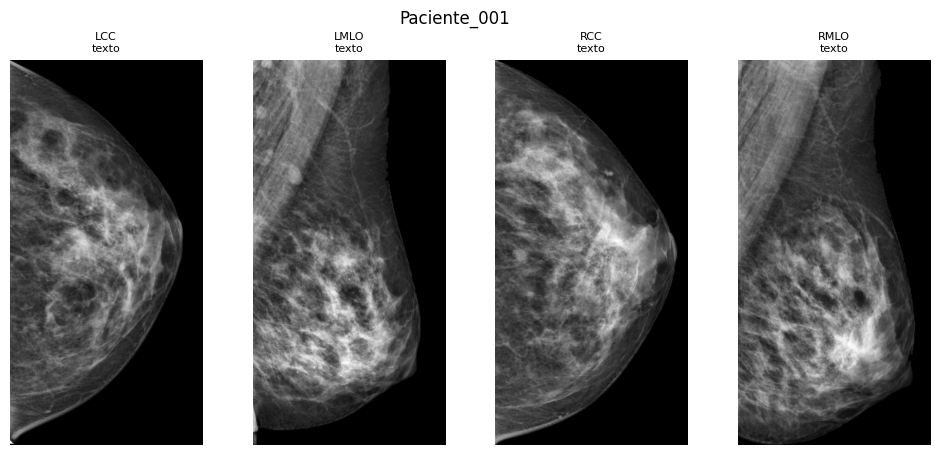

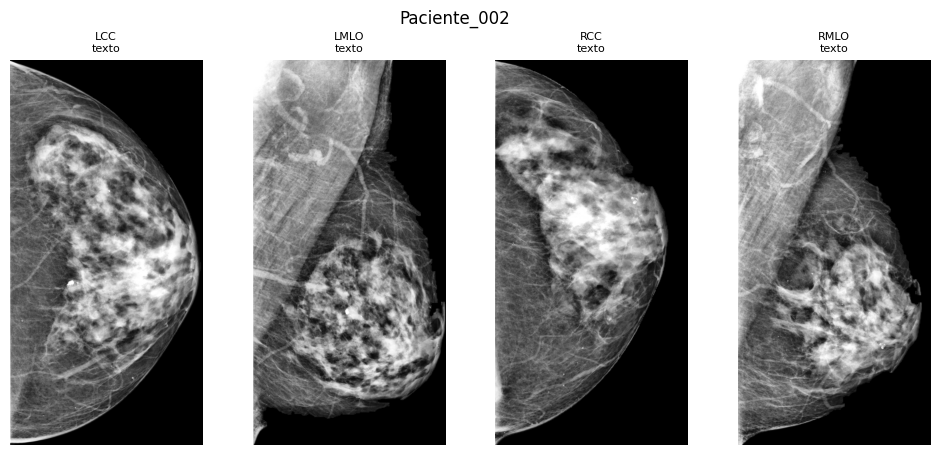

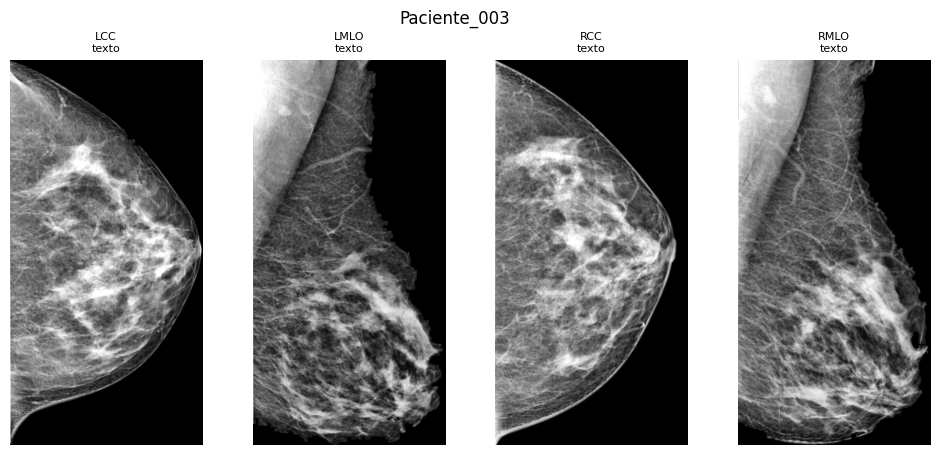

In [7]:
rev_path = f"{LAB}/vistas_revision.csv"
dudosas = inv[(inv.lat_source != "tag") | (~inv.proj_source.isin(["tag", "texto"]))]
if os.path.exists(rev_path):                       # aplica correcciones manuales previas
    rev = pd.read_csv(rev_path)
    inv = inv.drop(columns=["laterality", "projection"]).merge(
        rev[["image_id", "laterality", "projection"]], on="image_id", how="left").fillna({"laterality": "U", "projection": "U"})
    print("Correcciones manuales aplicadas:", len(rev))
elif len(dudosas):
    dudosas[["image_id", "patient_id", "dicom_file", "laterality", "lat_source", "projection", "proj_source"]].to_csv(rev_path, index=False)
    print(f"{len(dudosas)} imágenes con vista inferida -> revisar {rev_path}")

def show_patient(pid, n=4):
    g = inv[inv.patient_id == pid].sort_values(["laterality", "projection"]).head(n)
    fig, ax = plt.subplots(1, len(g), figsize=(3 * len(g), 5))
    for a, r in zip(np.atleast_1d(ax), g.itertuples()):
        a.imshow(cv2.imread(r.img_path, 0), cmap="gray"); a.set_title(f"{r.laterality}{r.projection}\n{r.proj_source}", fontsize=8); a.axis("off")
    plt.suptitle(pid); plt.show()
for pid in inv.patient_id.drop_duplicates().head(3):
    show_patient(pid)

## 3 · Etiquetas a partir de los reportes del radiólogo
El extractor por reglas (`mamoia/text/report_parser.py`) anonimiza el texto (quita nombres de médicos y
fechas) y extrae: BI-RADS y subcategoría, densidad ACR, **lateralidad del hallazgo**, tipo de lesión (con
manejo de negaciones: *"sin nódulos"*), cuadrante, tamaño, márgenes y **resultado de biopsia** cuando el
addendum lo reporta.

In [8]:
xlsx = sorted(glob.glob(f"{XLSX_DIR}/*.xlsx"))
if not xlsx:
    from google.colab import files
    os.makedirs(XLSX_DIR, exist_ok=True)
    print("Sube los 3 Excel PX_*.xlsx")
    for name, data in files.upload().items():
        open(f"{XLSX_DIR}/{name}", "wb").write(data)
    xlsx = sorted(glob.glob(f"{XLSX_DIR}/*.xlsx"))
print(xlsx)

Sube los 3 Excel PX_*.xlsx


Saving PX_1-15_B3-B4-B5.xlsx to PX_1-15_B3-B4-B5.xlsx
Saving PX_16-53_B3-B4-B5.xlsx to PX_16-53_B3-B4-B5.xlsx
Saving PX_54-119_B3-B4-B5.xlsx to PX_54-119_B3-B4-B5.xlsx
['/content/drive/MyDrive/MamoIA/reportes/PX_1-15_B3-B4-B5.xlsx', '/content/drive/MyDrive/MamoIA/reportes/PX_16-53_B3-B4-B5.xlsx', '/content/drive/MyDrive/MamoIA/reportes/PX_54-119_B3-B4-B5.xlsx']


In [9]:
from mamoia.text.report_parser import parse_all, expand_to_breasts, breast_targets
rep = parse_all(xlsx)
rep.to_csv(f"{LAB}/reportes_extraidos.csv", index=False, encoding="utf-8-sig")
print(len(rep), "reportes")
for c in ["birads", "birads_sub", "density", "lesion_laterality", "lesion_type", "lesion_quadrant", "biopsy_result"]:
    print(f"{c:18s}", rep[c].value_counts(dropna=False).to_dict())
display(rep[["patient_id", "birads", "birads_sub", "density", "lesion_laterality", "lesion_type",
             "lesion_quadrant", "lesion_size_mm", "biopsy_result", "impresion"]].head(12))

119 reportes
birads             {4: 71, 5: 43, 3: 5}
birads_sub         {None: 57, '4b': 30, '4a': 20, '4c': 12}
density            {'C': 48, 'B': 40, 'A': 14, None: 11, 'D': 6}
lesion_laterality  {'L': 49, 'R': 42, 'U': 15, 'B': 13}
lesion_type        {'masa': 80, 'microcalcificaciones': 17, 'ninguna': 14, 'asimetria': 6, 'distorsion': 2}
lesion_quadrant    {None: 55, 'CSE': 41, 'retroareolar': 13, 'CSI': 4, 'CIE': 3, 'CII': 2, 'axilar': 1}
biopsy_result      {None: 104, 'pendiente': 9, 'maligno': 3, 'benigno': 3}


,patient_id,birads,birads_sub,density,lesion_laterality,lesion_type,lesion_quadrant,lesion_size_mm,biopsy_result,impresion
0,Paciente_001,3,None,None,U,ninguna,None,NaN,None,1.-BIRADS 3. 2.-Hallazgos probablemente benignos.
1,Paciente_002,3,None,C,U,masa,None,NaN,None,1.-BIRADS 3. 2.-Hallazgos probablemente benignos.
2,Paciente_003,3,None,C,R,asimetria,CSE,NaN,None,"ESTUDIO NEGATIVO A MALIGNIDAD, CATEGORIA BIRADS 3, CAMBIOS BENIGNOS HABITUALES A CONDICION FIBROQUISTICA SIN LESIONE..."
3,Paciente_004,3,None,C,B,masa,None,14.0,None,Condición fibroquística Patron mamario mixto denso Continuar control semestral (estudio previo con asimetría focal d...
4,Paciente_005,3,None,B,L,masa,None,NaN,None,"Patron mamario mixto con fibrosis Densidad asimétrica ICInt izquierdos, control en 6 meses Clasificación BIRADS - 3 ..."
5,Paciente_006,4,None,None,U,ninguna,None,NaN,None,HALLAZGOS EN RELACIÓN A LA CATEGORÍA 4 DE LA CLASIFICACIÓN DE BI RADS DEL COLEGIO AMERICANO DE RADIOLOGÍA. SE RECOMI...
6,Paciente_007,4,None,None,R,asimetria,None,NaN,None,HALLAZGOS EN RELACIÓN A LA CATEGORÍA 4 DE LA CLASIFICACIÓN DE BI RADS DEL COLEGIO AMERICANO DE RADIOLOGÍA. SE RECOMI...
7,Paciente_008,4,None,C,L,masa,CSE,60.0,None,Condición fibroquística Tejido accesorio axilar Conglomerado de microcalcificaciones CSE izquierdo Clasificación BIR...
8,Paciente_009,4,None,None,U,microcalcificaciones,None,NaN,None,
9,Paciente_010,4,4b,None,L,asimetria,retroareolar,NaN,None,"BI-RADS 4b. Radiodensidad retroareolar izquierda que causa distorción de la arquitectura, que requiere biopsia. Teji..."


**Ejercicio:** elijan 20 reportes al azar, lean el texto (`rep.report_anon`) y verifiquen a mano la
lateralidad y el tipo de lesión. ¿Qué exactitud tiene el extractor? ¿Qué patrones fallan?

In [10]:
# (opcional) extracción con LLM y concordancia con las reglas
if USE_LLM_FOR_LABELS and LLM_BACKEND in ("claude", "ollama"):
    from mamoia.llm.extract import extract_fields, compare, cache_json
    llm_rows = []
    for r in rep.itertuples():
        d = cache_json(f"{LAB}/llm_cache/extract_{r.patient_id}.json", extract_fields, r.report_anon, LLM_BACKEND)
        llm_rows.append({"patient_id": r.patient_id, **d})
    llm = pd.DataFrame(llm_rows)
    llm.to_csv(f"{LAB}/reportes_extraidos_llm.csv", index=False)
    display(pd.DataFrame(compare(rep, llm)).T)
    dis = rep.merge(llm, on="patient_id", suffixes=("_reglas", "_llm"))
    display(dis[dis.lesion_laterality_reglas != dis.lesion_laterality_llm][["patient_id", "lesion_laterality_reglas", "lesion_laterality_llm", "impresion"]])
else:
    print("Extracción con LLM desactivada (USE_LLM_FOR_LABELS=False)")

Extracción con LLM desactivada (USE_LLM_FOR_LABELS=False)


## 4 · Ground truth débil por mama y por imagen
Todos los estudios son BI-RADS 3-5 (no hay controles normales). Estrategia:

* **Mama con el hallazgo** → recibe la categoría del reporte. **Mama contralateral** (si el hallazgo es
  claramente unilateral y no hay mastectomía) → *sin hallazgo sospechoso* (negativo).
* Si la biopsia está reportada, **manda la biopsia** (maligno = 1, benigno = 0).
* `TARGET`:
  * `b5_vs_resto`: 1 = BI-RADS 5 / biopsia maligna; 0 = BI-RADS 3-4, contralateral, biopsia benigna.
  * `b45_vs_resto`: 1 = BI-RADS 4-5; 0 = BI-RADS 3 y contralaterales.
  * `hallazgo_vs_contralateral`: detección (¿esta mama tiene el hallazgo reportado?).

> Es una etiqueta **derivada del radiólogo**, no histopatológica: el modelo aprende a reproducir la
> lectura del radiólogo. Discútanlo en el informe.

In [11]:
from mamoia.data.labels import build_image_labels
breasts = breast_targets(expand_to_breasts(rep), TARGET)
breasts.to_csv(f"{LAB}/reportes_por_mama.csv", index=False)
img_lab = build_image_labels(inv, breasts)
img_lab["preprocessed"] = True
labels_csv = f"{LAB}/labels_dicom_{TARGET}.csv"
img_lab.to_csv(labels_csv, index=False)

sin_reporte = sorted(set(inv.patient_id) - set(rep.patient_id))
sin_imagen = sorted(set(rep.patient_id) - set(inv.patient_id))
print("Pacientes con imágenes y sin reporte:", sin_reporte[:10], "…" if len(sin_reporte) > 10 else "")
print("Pacientes con reporte y sin imágenes:", sin_imagen[:10], "…" if len(sin_imagen) > 10 else "")
print("\nImágenes por etiqueta:", img_lab.y_malig.value_counts().to_dict())
display(pd.crosstab(img_lab.label_source.fillna("sin etiqueta"), img_lab.y_malig, margins=True))

Pacientes con imágenes y sin reporte: [] 
Pacientes con reporte y sin imágenes: [] 

Imágenes por etiqueta: {0: 383, 1: 112, -1: 2}


y_malig,-1,0,1,All
label_source,,,,
bilateral,0,34,19,53
biopsia,0,6,6,12
contralateral,0,181,0,181
excluida,2,0,0,2
hallazgo,0,113,75,188
paciente,0,46,12,58
paciente(U),0,3,0,3
All,2,383,112,497


## 5 · Clasificador CNN con validación cruzada por paciente

In [12]:
OV = (f'--set classifier.backbone={BACKBONE} --set "classifier.img_size={IMG_SIZE}" '
      f'--set train.epochs={EPOCHS} --set train.batch_size={BATCH} --set train.num_workers=2')
INIT = ""
if CBIS_PRETRAIN:
    sh("pip -q install kagglehub")
    import kagglehub
    root = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")
    os.makedirs("data/public", exist_ok=True)
    if not os.path.exists("data/public/cbis-ddsm"):
        os.symlink(root, "data/public/cbis-ddsm")
    if not os.path.exists(f"{CKPT}/cls_cbis.pt"):
        sh(f"python -m mamoia.train.train_classifier --source public --out {CKPT}/cls_cbis.pt {OV} --set train.epochs=10")
    INIT = f"--init {CKPT}/cls_cbis.pt"

for k in range(N_FOLDS):
    out = f"{CKPT}/cv/fold{k}.pt"
    if os.path.exists(out.replace(".pt", ".oof.csv")):
        print(f"fold {k} ya entrenado"); continue
    sh(f"python -m mamoia.train.train_classifier --source csv --labels-csv {labels_csv} "
       f"--n-folds {N_FOLDS} --fold {k} --out {out} {INIT} {OV}")

$ python -m mamoia.train.train_classifier --source csv --labels-csv /content/drive/MyDrive/MamoIA/labels/labels_dicom_b5_vs_resto.csv --n-folds 5 --fold 0 --out /content/drive/MyDrive/MamoIA/checkpoints/cv/fold0.pt  --set classifier.backbone=efficientnet_b0 --set "classifier.img_size=[1024, 512]" --set train.epochs=20 --set train.batch_size=8 --set train.num_workers=2
  warnings.warn(
         n  malignos  benignos
split                         
test    94        20        72
train  346        78       268
val     57        14        43
Fuente de la etiqueta: {'hallazgo': 188, 'contralateral': 181, 'paciente': 58, 'bilateral': 53, 'biopsia': 12, 'paciente(U)': 3, 'excluida': 2}
  sched.step()
ép 01 | loss 1.7135 | val AUC 0.704 | sens 0.93 | 21s
ép 02 | loss 1.2089 | val AUC 0.650 | sens 0.79 | 11s
ép 03 | loss 1.1152 | val AUC 0.613 | sens 0.36 | 11s
ép 04 | loss 0.8395 | val AUC 0.774 | sens 1.00 | 10s
ép 05 | loss 0.7945 | val AUC 0.766 | sens 0.64 | 10s
ép 06 | loss 0.6226 | val AU

,n,auc,auc_ic95,sensibilidad,especificidad,vpp,vpn,sens_a_esp_0.80
image,495,0.649688,"(0.562608373301359, 0.7257236019812164)",0.651786,0.516971,0.282946,0.835443,0.473214
breast,234,0.658696,"(0.5641109319742043, 0.7486988364178334)",0.7,0.440217,0.253623,0.84375,0.48
patient,119,0.622121,"(0.5058633355061926, 0.736364710939179)",0.727273,0.253333,0.363636,0.612903,0.522727


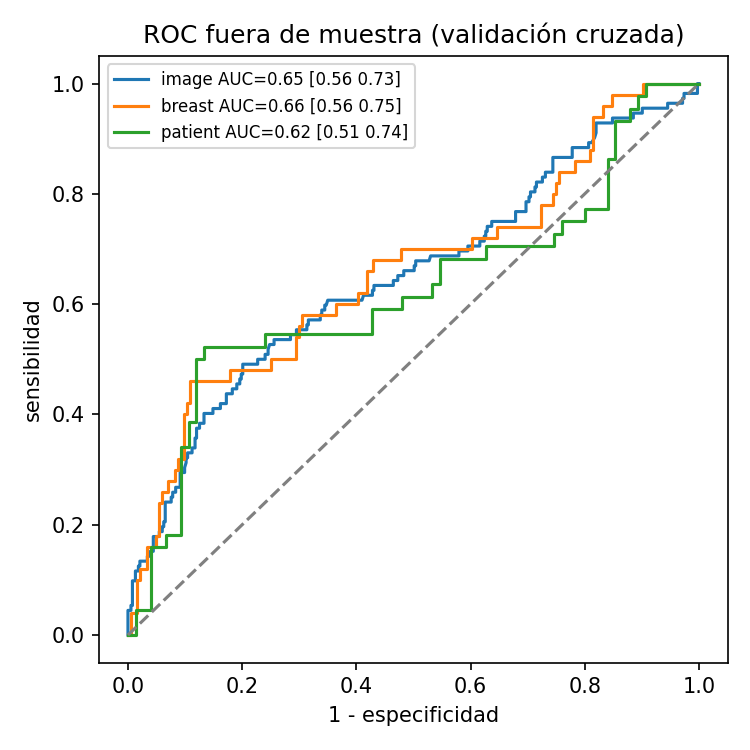

In [13]:
from mamoia.train.evaluate_cv import evaluate_oof
oof = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(f"{CKPT}/cv/fold*.oof.csv"))], ignore_index=True)
res = evaluate_oof(oof, f"{OUTD}/cv")
tabla = pd.DataFrame({lvl: {k: m.get(k) for k in ("n", "auc", "auc_ic95", "sensibilidad", "especificidad",
                                                  "vpp", "vpn", "sens_a_esp_0.80")} for lvl, m in res.items()}).T
display(tabla)
from IPython.display import Image
display(Image(f"{OUTD}/cv/roc_cv.png"))

**Cómo leerlo:** *imagen* = cada vista por separado; *mama* = promedio de CC y MLO; *paciente* =
la mama más sospechosa. El IC 95 % viene de remuestrear pacientes (bootstrap). Con ~119 pacientes los
intervalos son amplios: repórtenlos siempre.

## 6 · Explicabilidad sobre casos fuera de muestra (Grad-CAM vs. CADe de la tesis)

In [14]:
import torch
from mamoia.models.classifier import load_classifier
from mamoia.explain.gradcam import gradcam, overlay
from mamoia.classic.cade import detect_rois, draw_rois
from mamoia.data.dataset import to_tensor
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
o = oof.merge(img_lab[["image_id", "img_path"]], on="image_id")
casos = pd.concat([o[o.y_malig == 1].nlargest(3, "p_malig").assign(tipo="VP"),
                   o[o.y_malig == 0].nlargest(2, "p_malig").assign(tipo="FP"),
                   o[o.y_malig == 1].nsmallest(2, "p_malig").assign(tipo="FN")])
for r in casos.itertuples():
    model, ck = load_classifier(f"{CKPT}/cv/fold{int(r.fold)}.pt", dev); model.to(dev)
    img = cv2.imread(r.img_path, 0); img = cv2.resize(img, (ck["img_size"][1], ck["img_size"][0]))
    mask = img > 0
    heat = gradcam(model, to_tensor(img).unsqueeze(0).to(dev))
    cade = detect_rois(img, mask)
    fig, ax = plt.subplots(1, 3, figsize=(10, 6))
    ax[0].imshow(img, cmap="gray"); ax[1].imshow(overlay(img, heat)[..., ::-1]); ax[2].imshow(draw_rois(img, cade["rois"])[..., ::-1])
    for a, t in zip(ax, ["imagen", "Grad-CAM (CNN)", "CADe tesis 2015"]): a.set_title(t); a.axis("off")
    plt.suptitle(f"{r.tipo} · {r.image_id} · P={r.p_malig:.2f} · y={r.y_malig}"); plt.show()

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


## 7 · Modelo final y captioner CNN-LSTM
El modelo final se entrena con todos los pacientes (dejando un 10 % para test rápido); el desempeño a
reportar es el de la validación cruzada. Los textos objetivo del LSTM se construyen por mama a partir de
los campos extraídos del reporte (o con resúmenes del LLM si `USE_LLM_FOR_LABELS=True`).

In [15]:
FINAL = f"{CKPT}/classifier.pt"
if not os.path.exists(FINAL):
    sh(f"python -m mamoia.train.train_classifier --source csv --labels-csv {labels_csv} --out {FINAL} "
       f"{INIT} {OV} --set train.test_frac=0.1")
print(json.load(open(FINAL.replace(".pt", ".test.json")))["malignidad"])

$ python -m mamoia.train.train_classifier --source csv --labels-csv /content/drive/MyDrive/MamoIA/labels/labels_dicom_b5_vs_resto.csv --out /content/drive/MyDrive/MamoIA/checkpoints/classifier.pt  --set classifier.backbone=efficientnet_b0 --set "classifier.img_size=[1024, 512]" --set train.epochs=20 --set train.batch_size=8 --set train.num_workers=2 --set train.test_frac=0.1
  warnings.warn(
  warnings.warn(
         n  malignos  benignos
split                         
test    51         6        45
train  367        85       280
val     79        21        58
Fuente de la etiqueta: {'hallazgo': 188, 'contralateral': 181, 'paciente': 58, 'bilateral': 53, 'biopsia': 12, 'paciente(U)': 3, 'excluida': 2}
  sched.step()
ép 01 | loss 1.7034 | val AUC 0.603 | sens 0.48 | 17s
ép 02 | loss 1.3520 | val AUC 0.622 | sens 0.48 | 12s
ép 03 | loss 1.2433 | val AUC 0.615 | sens 0.57 | 12s
ép 04 | loss 1.0666 | val AUC 0.647 | sens 0.57 | 12s
ép 05 | loss 0.9150 | val AUC 0.695 | sens 0.52 | 12s
ép 0

In [16]:
cap_csv = labels_csv.replace(".csv", "_caption.csv")
cap = img_lab.copy()
if USE_LLM_FOR_LABELS and LLM_BACKEND in ("claude", "ollama"):
    from mamoia.llm.extract import summarize_breast, cache_json
    txt = {}
    for r in rep.itertuples():
        for side in ("L", "R"):
            txt[(r.patient_id, side)] = cache_json(f"{LAB}/llm_cache/sum_{r.patient_id}_{side}.json",
                                                   summarize_breast, r.report_anon, side, LLM_BACKEND)
    cap["report_text"] = [txt.get((p, l), "") for p, l in zip(cap.patient_id, cap.laterality)]
cap.to_csv(cap_csv, index=False)
from mamoia.text.report_templates import describe
for r in cap.sample(3, random_state=1).to_dict("records"):
    print("·", describe(r))
if not os.path.exists(f"{CKPT}/captioner.pt"):
    sh(f"python -m mamoia.train.train_captioner --classifier {FINAL} --source csv --labels-csv {cap_csv} "
       f"--out {CKPT}/captioner.pt --set captioner.epochs=30 --set train.num_workers=2")

· Mama derecha, proyección CC. Patrón de mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas.
· Mama derecha, proyección MLO. Patrón de mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas.
· Mama izquierda, proyección CC. Patrón de mama heterogéneamente densa (ACR C). Se identifica masa. Impresión: hallazgo sospechoso de malignidad. BI-RADS 4.
$ python -m mamoia.train.train_captioner --classifier /content/drive/MyDrive/MamoIA/checkpoints/classifier.pt --source csv --labels-csv /content/drive/MyDrive/MamoIA/labels/labels_dicom_b5_vs_resto_caption.csv --out /content/drive/MyDrive/MamoIA/checkpoints/captioner.pt --set captioner.epochs=30 --set train.num_workers=2
  warnings.warn(
  warnings.warn(
vocabulario: 105 palabras | ejemplo: Sin masas, asimetrías ni microcalcificaciones sospechosas. Impresión: hallazgo probablemente benigno. BI-RADS 3.
ép 01 | loss 3.229 | BLEU-4 0.398 | BI-RADS ok 0.543478260869

## 8 · Reporte bilateral con LLM y comparación con el radiólogo

In [17]:
from mamoia.pipeline import MamoPipeline
pipe = MamoPipeline.load(FINAL, f"{CKPT}/captioner.pt", cfg=cfg)
from mamoia.train.common import build_dataframe
# mismos pacientes de test (10 %) que usó el modelo final
dfF = build_dataframe(load_config(overrides=["train.test_frac=0.1"]), "csv", labels_csv=labels_csv)
pats = dfF[dfF.split == "test"].patient_id.unique()[:6]
filas = []
for pid in pats:
    g = img_lab[(img_lab.patient_id == pid) & img_lab.laterality.isin(["L", "R"])]
    study = [(f"{DICOM_DIR}/{r.dicom_file}", r.laterality, r.projection) for r in g.itertuples()]
    out = pipe.analyze_study(study, llm=LLM_BACKEND)
    rr = rep.set_index("patient_id").loc[pid]
    filas.append({"paciente": pid, "BI-RADS radiólogo": rr.birads, "lado radiólogo": rr.lesion_laterality,
                  "BI-RADS IA": out["reporte"]["report"]["birads_sugerido"],
                  "lado IA": {"izquierda": "L", "derecha": "R"}.get(out["reporte"]["findings"]["mama_de_mayor_sospecha"]),
                  "P(mal) L": out["por_mama"].get("L", {}).get("clasificador", {}).get("prob_malignidad"),
                  "P(mal) R": out["por_mama"].get("R", {}).get("clasificador", {}).get("prob_malignidad")})
    display(Markdown(f"---\n## {pid} · radiólogo: BI-RADS {rr.birads} ({rr.lesion_laterality})\n" + out["reporte"]["markdown"]))
comp = pd.DataFrame(filas); display(comp)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=6.
  warnings.warn(


---
## Paciente_010 · radiólogo: BI-RADS 4 (L)
### Hallazgos
**Mama izquierda.** Proyección MLO mama izquierda. Descripción automática (LSTM): Se observa mama predominantemente grasa (ACR A). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 1%. La mayor activación del modelo se ubica en el tercio posterior, región superior de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

**Mama derecha.** Proyección MLO mama derecha. Descripción automática (LSTM): Se observa mama predominantemente grasa (ACR A). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 1%. La mayor activación del modelo se ubica en el tercio posterior, región superior de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

### Impresión
Estudio bilateral: categoría sugerida BI-RADS 2, a expensas de la mama izquierda (borrador generado por IA).

**Categoría BI-RADS sugerida:** 2  ·  **Confianza del modelo:** moderado

### Recomendaciones para el radiólogo
- Mama izquierda: Conducta sugerida para BI-RADS 2: Tamizaje de rutina (mastografía cada 2 años en mujeres de 40 a 69 años, NOM-041).
- Discordancia interna entre las salidas del modelo: interpretar con especial cautela.
- Correlacionar con la proyección contralateral/ortogonal, estudios previos y la clínica.

### Limitaciones
Modelo experimental con fines docentes; requiere validación por radiólogo.

> BORRADOR GENERADO POR IA CON FINES DOCENTES Y DE INVESTIGACIÓN. No constituye un diagnóstico; debe ser revisado y firmado por un médico radiólogo.

---
## Paciente_026 · radiólogo: BI-RADS 5 (L)
### Hallazgos
**Mama izquierda.** Proyección CC mama izquierda. Descripción automática (LSTM): Se observa mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 48%. La mayor activación del modelo se ubica en el tercio medio, región central de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

**Mama derecha.** Proyección CC mama derecha. Descripción automática (LSTM): Se observa mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 11%. La mayor activación del modelo se ubica en el tercio medio, región central de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

### Impresión
Estudio bilateral: categoría sugerida BI-RADS 3, a expensas de la mama izquierda (borrador generado por IA).

**Categoría BI-RADS sugerida:** 3  ·  **Confianza del modelo:** moderado

### Recomendaciones para el radiólogo
- Mama izquierda: Conducta sugerida para BI-RADS 3: Seguimiento a corto plazo: mastografía unilateral a los 6 meses y luego a los 12 y 24 meses.
- Mama densa (ACR C/D): la sensibilidad de la mastografía disminuye; considerar ultrasonido complementario según criterio del radiólogo.
- Revisar con atención la zona media / región central de la imagen (máxima activación del modelo).
- Correlacionar con la proyección contralateral/ortogonal, estudios previos y la clínica.

### Limitaciones
Modelo experimental con fines docentes; requiere validación por radiólogo.

> BORRADOR GENERADO POR IA CON FINES DOCENTES Y DE INVESTIGACIÓN. No constituye un diagnóstico; debe ser revisado y firmado por un médico radiólogo.

---
## Paciente_029 · radiólogo: BI-RADS 5 (L)
### Hallazgos
**Mama izquierda.** Proyección CC mama izquierda. Descripción automática (LSTM): Se observa mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 77%. La mayor activación del modelo se ubica en el tercio posterior, región superior de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

**Mama derecha.** Proyección MLO mama derecha. Descripción automática (LSTM): Se observa mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 21%. La mayor activación del modelo se ubica en el tercio anterior, región central de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

### Impresión
Estudio bilateral: categoría sugerida BI-RADS 4, a expensas de la mama izquierda (borrador generado por IA).

**Categoría BI-RADS sugerida:** 4  ·  **Confianza del modelo:** moderado

### Recomendaciones para el radiólogo
- Mama izquierda: Conducta sugerida para BI-RADS 4: Diagnóstico tisular: biopsia guiada por imagen.
- Revisar con atención la zona posterior / región superior de la imagen (máxima activación del modelo).
- Correlacionar con la proyección contralateral/ortogonal, estudios previos y la clínica.

### Limitaciones
Modelo experimental con fines docentes; requiere validación por radiólogo.

> BORRADOR GENERADO POR IA CON FINES DOCENTES Y DE INVESTIGACIÓN. No constituye un diagnóstico; debe ser revisado y firmado por un médico radiólogo.

---
## Paciente_048 · radiólogo: BI-RADS 5 (L)
### Hallazgos
**Mama izquierda.** Proyección MLO mama izquierda. Descripción automática (LSTM): Se observa densidades fibroglandulares dispersas (ACR B). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 17%. La mayor activación del modelo se ubica en el tercio posterior, región superior de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

**Mama derecha.** Proyección CC mama derecha. Descripción automática (LSTM): Se observa mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 15%. La mayor activación del modelo se ubica en el tercio posterior, región central de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

### Impresión
Estudio bilateral: categoría sugerida BI-RADS 3, a expensas de la mama izquierda (borrador generado por IA).

**Categoría BI-RADS sugerida:** 3  ·  **Confianza del modelo:** moderado

### Recomendaciones para el radiólogo
- Mama izquierda: Conducta sugerida para BI-RADS 3: Seguimiento a corto plazo: mastografía unilateral a los 6 meses y luego a los 12 y 24 meses.
- Revisar con atención la zona posterior / región superior de la imagen (máxima activación del modelo).
- Correlacionar con la proyección contralateral/ortogonal, estudios previos y la clínica.

### Limitaciones
Modelo experimental con fines docentes; requiere validación por radiólogo.

> BORRADOR GENERADO POR IA CON FINES DOCENTES Y DE INVESTIGACIÓN. No constituye un diagnóstico; debe ser revisado y firmado por un médico radiólogo.

---
## Paciente_054 · radiólogo: BI-RADS 4 (L)
### Hallazgos
**Mama izquierda.** Proyección MLO mama izquierda. Descripción automática (LSTM): Se observa mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 41%. La mayor activación del modelo se ubica en el tercio posterior, región central de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

**Mama derecha.** Proyección MLO mama derecha. Descripción automática (LSTM): Se observa mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 10%. La mayor activación del modelo se ubica en el tercio posterior, región superior de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

### Impresión
Estudio bilateral: categoría sugerida BI-RADS 3, a expensas de la mama izquierda (borrador generado por IA).

**Categoría BI-RADS sugerida:** 3  ·  **Confianza del modelo:** moderado

### Recomendaciones para el radiólogo
- Mama izquierda: Conducta sugerida para BI-RADS 3: Seguimiento a corto plazo: mastografía unilateral a los 6 meses y luego a los 12 y 24 meses.
- Revisar con atención la zona posterior / región central de la imagen (máxima activación del modelo).
- Correlacionar con la proyección contralateral/ortogonal, estudios previos y la clínica.

### Limitaciones
Modelo experimental con fines docentes; requiere validación por radiólogo.

> BORRADOR GENERADO POR IA CON FINES DOCENTES Y DE INVESTIGACIÓN. No constituye un diagnóstico; debe ser revisado y firmado por un médico radiólogo.

---
## Paciente_070 · radiólogo: BI-RADS 4 (L)
### Hallazgos
**Mama izquierda.** Proyección CC mama izquierda. Descripción automática (LSTM): Se observa mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 6%. La mayor activación del modelo se ubica en el tercio medio, región superior de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

**Mama derecha.** Proyección CC mama derecha. Descripción automática (LSTM): Se observa mama heterogéneamente densa (ACR C). Sin masas, asimetrías ni microcalcificaciones sospechosas. El clasificador estima una probabilidad de malignidad de 36%. La mayor activación del modelo se ubica en el tercio posterior, región superior de la imagen. El CADe clásico (tesis 2015) marcó 25 regiones candidatas.

### Impresión
Estudio bilateral: categoría sugerida BI-RADS 3, a expensas de la mama derecha (borrador generado por IA).

**Categoría BI-RADS sugerida:** 3  ·  **Confianza del modelo:** moderado

### Recomendaciones para el radiólogo
- Mama derecha: Conducta sugerida para BI-RADS 3: Seguimiento a corto plazo: mastografía unilateral a los 6 meses y luego a los 12 y 24 meses.
- Mama densa (ACR C/D): la sensibilidad de la mastografía disminuye; considerar ultrasonido complementario según criterio del radiólogo.
- Revisar con atención la zona posterior / región superior de la imagen (máxima activación del modelo).
- Correlacionar con la proyección contralateral/ortogonal, estudios previos y la clínica.

### Limitaciones
Modelo experimental con fines docentes; requiere validación por radiólogo.

> BORRADOR GENERADO POR IA CON FINES DOCENTES Y DE INVESTIGACIÓN. No constituye un diagnóstico; debe ser revisado y firmado por un médico radiólogo.

,paciente,BI-RADS radiólogo,lado radiólogo,BI-RADS IA,lado IA,P(mal) L,P(mal) R
0,Paciente_010,4,L,2,L,0.007882,0.010293
1,Paciente_026,5,L,3,L,0.482583,0.113836
2,Paciente_029,5,L,4,L,0.774021,0.205912
3,Paciente_048,5,L,3,L,0.173129,0.151616
4,Paciente_054,4,L,3,L,0.408994,0.102214
5,Paciente_070,4,L,3,R,0.062793,0.363559


**Ejercicio:** extiendan la tabla a los pacientes fuera de muestra de *todos* los folds (usando el
modelo de cada fold) y calculen: concordancia de la mama más sospechosa con la lateralidad del reporte y
matriz de confusión BI-RADS IA vs. radiólogo. Pidan al radiólogo calificar 10 reportes a ciegas.

## 9 · Exportar para la API y la app web

In [18]:
dst = f"{WORK}/export_api"
os.makedirs(dst, exist_ok=True)
for f in ("classifier.pt", "captioner.pt"):
    shutil.copy(f"{CKPT}/{f}", f"{dst}/{f}")
json.dump({"target": TARGET, "n_folds": N_FOLDS, "backbone": BACKBONE, "img_size": IMG_SIZE,
           "cv": {k: {kk: v.get(kk) for kk in ("auc", "auc_ic95")} for k, v in res.items()}},
          open(f"{dst}/model_card.json", "w"), indent=2, default=str)
print("Listo:", os.listdir(dst))
print("Copien estos archivos a checkpoints/ de la API (api/Dockerfile) y sigan docs/LOVABLE_PROMPT.md")

Listo: ['classifier.pt', 'captioner.pt', 'model_card.json']
Copien estos archivos a checkpoints/ de la API (api/Dockerfile) y sigan docs/LOVABLE_PROMPT.md
